In [ ]:
pip install tensorflow torch torchvision

In [14]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# 1. Define the Dataset (The XOR logic)
# Inputs: [0,0], [0,1], [1,0], [1,1]
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
# Outputs: 0, 1, 1, 0
y = np.array([[0], [1], [1], [0]])

# 2. Build the Neural Network
model = Sequential([
    # Hidden layer with 8 neurons and ReLU activation
    # input_dim=2 because we have 2 features (the two numbers)
    Dense(8, input_dim=2, activation='relu'), 
    
    # Output layer with 1 neuron and Sigmoid activation (outputs a probability between 0 and 1)
    Dense(1, activation='sigmoid')
])

# 3. Compile the Model
# Binary crossentropy is perfect for yes/no (1/0) classification
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 4. Train the Model
print("Training the XOR Model...")
# We train for 500 epochs (iterations) because it's a very tiny dataset
model.fit(X, y, epochs=1000, verbose=0) 

# 5. Test the Model
print("\nTesting the Model's Predictions:")
predictions = model.predict(X)

for i in range(len(X)):
    print(f"Input: {X[i]} | Predicted: {predictions[i][0]:.4f} | Actual: {y[i][0]}")

Training the XOR Model...

Testing the Model's Predictions:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Input: [0 0] | Predicted: 0.2041 | Actual: 0
Input: [0 1] | Predicted: 0.8238 | Actual: 1
Input: [1 0] | Predicted: 0.8289 | Actual: 1
Input: [1 1] | Predicted: 0.1675 | Actual: 0


In [18]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout

# 1. Load the MNIST Dataset
# Keras has this built-in, so we can download it directly
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# 2. Preprocess the Data
# Pixel values range from 0 to 255. Neural networks prefer small numbers, 
# so we scale the values to be between 0 and 1.
x_train, x_test = x_train / 255.0, x_test / 255.0

# 3. Build the Neural Network
model = Sequential([
    # The images are 28x28 grids. Flatten turns them into a single line of 784 pixels.
    Flatten(input_shape=(28, 28)),
    
    # Hidden layer with 128 neurons
    Dense(128, activation='relu'),
    
    # Dropout randomly turns off 20% of neurons to prevent overfitting (memorizing the data)
    Dropout(0.2),


    
    # Output layer with 10 neurons (one for each digit: 0 through 9)
    # Softmax ensures the outputs are probabilities that sum to 100%
    Dense(10, activation='softmax')
])

# 4. Compile the Model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 5. Train the Model
print("Training the MNIST Digit Recognizer...")
model.fit(x_train, y_train, epochs=20)

# 6. Evaluate the Model on unseen Test Data
print("\nEvaluating model on test data...")
test_loss, test_acc = model.evaluate(x_test,  y_test, verbose=2)

print(f"\nFinal Test Accuracy: {test_acc * 100:.2f}%")

Training the MNIST Digit Recognizer...
Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9109 - loss: 0.3028
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9572 - loss: 0.1442
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9671 - loss: 0.1078
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9714 - loss: 0.0897
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9758 - loss: 0.0750
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9791 - loss: 0.0664
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9810 - loss: 0.0587
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9828 - loss: 0.0526
Epoch 9/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9844 - loss: 0.0470
Epoch 10/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9852 - loss: 0.0445
Epoch 11/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9851 - loss

# Pytorch examples

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim

# 1. Define the Dataset (The XOR logic)
# We use float32 tensors because PyTorch expects floats for weights and inputs
X = torch.tensor([[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]])
y = torch.tensor([[0.0], [1.0], [1.0], [0.0]])

# 2. Build the Neural Network
# nn.Sequential works just like it does in Keras
model = nn.Sequential(
    nn.Linear(2, 8),      # Hidden layer: 2 inputs, 8 neurons
    nn.ReLU(),            # Activation function
    nn.Linear(8, 1),      # Output layer: 8 inputs, 1 output
    nn.Sigmoid()          # Output a probability between 0 and 1
)

# 3. Define the Loss and Optimizer
criterion = nn.BCELoss() # Binary Cross Entropy Loss
optimizer = optim.Adam(model.parameters(), lr=0.01)

# 4. Train the Model (The explicit PyTorch loop!)
print("Training the XOR Model...")
epochs = 500

for epoch in range(epochs):
    # Forward pass: Make predictions
    predictions = model(X)
    
    # Calculate how wrong the predictions are
    loss = criterion(predictions, y)
    
    # Backward pass and optimization
    optimizer.zero_grad() # Clear old gradients
    loss.backward()       # Calculate new gradients (backpropagation)
    optimizer.step()      # Update the weights

# 5. Test the Model
print("\nTesting the Model's Predictions:")
# torch.no_grad() tells PyTorch to stop tracking gradients since we are just testing
with torch.no_grad(): 
    final_preds = model(X)
    for i in range(len(X)):
        print(f"Input: {X[i].tolist()} | Predicted: {final_preds[i][0]:.4f} | Actual: {y[i][0]:.0f}")

Training the XOR Model...

Testing the Model's Predictions:
Input: [0.0, 0.0] | Predicted: 0.0051 | Actual: 0
Input: [0.0, 1.0] | Predicted: 0.9947 | Actual: 1
Input: [1.0, 0.0] | Predicted: 0.9954 | Actual: 1
Input: [1.0, 1.0] | Predicted: 0.0051 | Actual: 0


In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. Load and Preprocess the MNIST Dataset
# transforms.ToTensor() converts the images to tensors AND automatically 
# scales the pixel values from 0-255 down to 0.0-1.0!
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# DataLoaders help us feed the data to the network in batches (e.g., 64 images at a time)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# 2. Build the Neural Network (Object-Oriented approach)
class MNISTClassifier(nn.Module):
    def __init__(self):
        super(MNISTClassifier, self).__init__()
        self.flatten = nn.Flatten()
        self.hidden1 = nn.Linear(28 * 28, 128)
        self.dropout = nn.Dropout(0.2)
        self.output = nn.Linear(128, 10)
        self.relu = nn.ReLU6()

    def forward(self, x):
        x = self.flatten(x)
        x = self.hidden1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.output(x)
        return x

model = MNISTClassifier()

# 3. Define Loss and Optimizer
# IMPORTANT: nn.CrossEntropyLoss automatically applies Softmax internally in PyTorch!
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 4. Train the Model
print("Training the MNIST Digit Recognizer...")
epochs = 5

for epoch in range(epochs):
    model.train() # Set model to training mode (turns on Dropout)
    running_loss = 0.0
    
    for images, labels in train_loader:
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    print(f"Epoch {epoch+1}/{epochs} - Loss: {running_loss/len(train_loader):.4f}")

# 5. Evaluate the Model
print("\nEvaluating model on test data...")
model.eval() # Set model to evaluation mode (turns off Dropout)
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        # Get the index of the highest predicted value
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"\nFinal Test Accuracy: {(100 * correct / total):.2f}%")

Training the MNIST Digit Recognizer...
Epoch 1/5 - Loss: 0.3790
Epoch 2/5 - Loss: 0.1810
Epoch 3/5 - Loss: 0.1336
Epoch 4/5 - Loss: 0.1083
Epoch 5/5 - Loss: 0.0915

Evaluating model on test data...

Final Test Accuracy: 97.15%


# Fashion classifier

Starting training on Fashion-MNIST...
Epoch [1/3] | Loss: 0.5293
Epoch [2/3] | Loss: 0.3781
Epoch [3/3] | Loss: 0.3413

Generating visual evaluation...


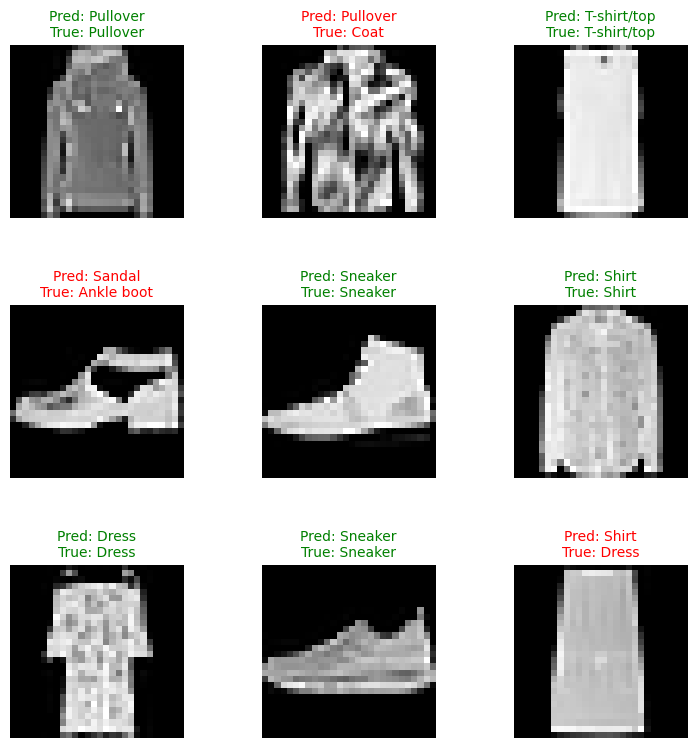

In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import random

# ==========================================
# 1. Data Preparation
# ==========================================
transform = transforms.ToTensor()

train_data = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_data = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

# Human-readable labels for Fashion-MNIST
classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# ==========================================
# 2. Model Architecture
# ==========================================
class FashionNet(nn.Module):
    def __init__(self):
        super(FashionNet, self).__init__()
        self.flatten = nn.Flatten()
        self.hidden1 = nn.Linear(28 * 28, 256)
        self.relu1 = nn.ReLU()
        self.hidden2 = nn.Linear(256, 64)
        self.relu2 = nn.ReLU()
        self.output = nn.Linear(64, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.hidden1(x)
        x = self.relu1(x)
        x = self.hidden2(x)
        x = self.relu2(x)
        x = self.output(x)
        return x

model = FashionNet()

# ==========================================
# 3. Training Setup
# ==========================================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ==========================================
# 4. The Training Loop (Shortened to 3 epochs for speed)
# ==========================================
print("Starting training on Fashion-MNIST...")
epochs = 3

for epoch in range(epochs):
    model.train() 
    running_loss = 0.0
    for images, labels in train_loader:
        predictions = model(images)
        loss = criterion(predictions, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        
    print(f"Epoch [{epoch+1}/{epochs}] | Loss: {running_loss / len(train_loader):.4f}")

# ==========================================
# 5. Visualizing Predictions
# ==========================================
print("\nGenerating visual evaluation...")
model.eval()

# Grab a single batch of images from the test loader
images, labels = next(iter(test_loader))

with torch.no_grad():
    outputs = model(images)
    _, predicted_classes = torch.max(outputs, 1)

# Setup a 3x3 grid plot
fig, axes = plt.subplots(3, 3, figsize=(9, 9))
fig.subplots_adjust(hspace=0.5, wspace=0.3)

# Pick 9 random indices from our test batch
random_indices = random.sample(range(len(images)), 9)

for i, idx in enumerate(random_indices):
    ax = axes[i // 3, i % 3]
    
    # PyTorch tensors are (Channels, Height, Width). 
    # Matplotlib expects (Height, Width) for grayscale, so we squeeze the channel dimension.
    img = images[idx].squeeze().numpy()
    
    pred_label = classes[predicted_classes[idx].item()]
    true_label = classes[labels[idx].item()]
    
    ax.imshow(img, cmap='gray')
    
    # Color code the text: Green if correct, Red if wrong
    color = 'green' if pred_label == true_label else 'red'
    
    ax.set_title(f"Pred: {pred_label}\nTrue: {true_label}", color=color, fontsize=10)
    ax.axis('off')

plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import random

# ==========================================
# 1. Data Preparation
# ==========================================
transform = transforms.ToTensor()

train_data = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_data = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

# Human-readable labels for Fashion-MNIST
classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# ==========================================
# 2. Model Architecture
# ==========================================
class FashionNet(nn.Module):
    def __init__(self):
        super(FashionNet, self).__init__()
        self.flatten = nn.Flatten()
        self.hidden1 = nn.Linear(28 * 28, 256)
        self.relu1 = nn.ReLU()
        self.hidden2 = nn.Linear(256, 64)
        self.relu2 = nn.ReLU()
        self.output = nn.Linear(64, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.hidden1(x)
        x = self.relu1(x)
        x = self.hidden2(x)
        x = self.relu2(x)
        x = self.output(x)
        return x

model = FashionNet()

# ==========================================
# 3. Training Setup
# ==========================================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ==========================================
# 4. The Training Loop (Shortened to 3 epochs for speed)
# ==========================================
print("Starting training on Fashion-MNIST...")
epochs = 3

for epoch in range(epochs):
    model.train() 
    running_loss = 0.0
    for images, labels in train_loader:
        predictions = model(images)
        loss = criterion(predictions, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        
    print(f"Epoch [{epoch+1}/{epochs}] | Loss: {running_loss / len(train_loader):.4f}")

# ==========================================
# 5. Visualizing Predictions
# ==========================================
print("\nGenerating visual evaluation...")
model.eval()

# Grab a single batch of images from the test loader
images, labels = next(iter(test_loader))

with torch.no_grad():
    outputs = model(images)
    _, predicted_classes = torch.max(outputs, 1)

# Setup a 3x3 grid plot
fig, axes = plt.subplots(3, 3, figsize=(9, 9))
fig.subplots_adjust(hspace=0.5, wspace=0.3)

# Pick 9 random indices from our test batch
random_indices = random.sample(range(len(images)), 9)

for i, idx in enumerate(random_indices):
    ax = axes[i // 3, i % 3]
    
    # PyTorch tensors are (Channels, Height, Width). 
    # Matplotlib expects (Height, Width) for grayscale, so we squeeze the channel dimension.
    img = images[idx].squeeze().numpy()
    
    pred_label = classes[predicted_classes[idx].item()]
    true_label = classes[labels[idx].item()]
    
    ax.imshow(img, cmap='gray')
    
    # Color code the text: Green if correct, Red if wrong
    color = 'green' if pred_label == true_label else 'red'
    
    ax.set_title(f"Pred: {pred_label}\nTrue: {true_label}", color=color, fontsize=10)
    ax.axis('off')

plt.show()